# 类别不均衡与真正的 Grad-CAM

比较损失、逐类召回、地图和类别梯度；不事先断言加权一定改进某一区域。

默认 demo 加载预先训练权重，核心算法在下方逐步演示。旧实验数字不作为本次结果。

In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/hsi_learning').is_dir() and (p / 'dataset').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the HSI-Learning repository')
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import torch
# Notebook kernels must explicitly use inline rendering even when the CLI
# parent uses MPLBACKEND=Agg for non-interactive training scripts.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import matplotlib.pyplot as plt
from hsi_learning.data import load_hsi_dataset
from hsi_learning.teaching_runs import load_bundle, encode_ids
from hsi_learning.teaching import patches_at, prototype_logits, prototypes, grad_cam
from hsi_learning.teaching_plots import style, maps
style()
torch.set_num_threads(2)
print('Python:', sys.executable)
print('Repository:', ROOT)


Python: D:\DevSpace\HSI-Learning\.venv\Scripts\python.exe
Repository: D:\DevSpace\HSI-Learning


In [2]:
# Classroom mode NEVER silently starts training.
MODE = 'demo'  # 'train' explicitly starts the full preparation queue below
BUNDLE_ROOT = ROOT / 'results/teaching_ready'
if MODE == 'train':
    import subprocess
    subprocess.run([sys.executable, str(ROOT/'scripts/prepare_teaching_artifacts.py')], check=True)
elif MODE != 'demo':
    raise ValueError('MODE must be demo or train')


In [3]:
ce,cube,gt,names,split,cfg=load_bundle(BUNDLE_ROOT/'classifier-ce')
weighted,cube_w,gt_w,_,split_w,cfg_w=load_bundle(BUNDLE_ROOT/'classifier-weighted')
np.testing.assert_array_equal(split['test_ids'],split_w['test_ids'])
np.testing.assert_allclose(cube,cube_w)
print('Same training/test centers and preprocessing; loss differs.')


Same training/test centers and preprocessing; loss differs.


CE OA: 0.9506097560975609 AA: 0.8028979593613078 per-class recall: [0.40540541 0.93607706 0.93825301 0.7989418  0.92764858 0.9880137
 0.09090909 1.         0.         0.92416452 0.97048346 0.95157895
 1.         1.         0.94155844 0.97333333]
Weighted CE OA: 0.9440243902439024 AA: 0.9345391514097021 per-class recall: [0.81081081 0.86865149 0.90361446 0.95767196 0.92764858 0.98458904
 0.72727273 1.         1.         0.94473008 0.95572519 0.91157895
 1.         0.99604743 0.96428571 1.        ]


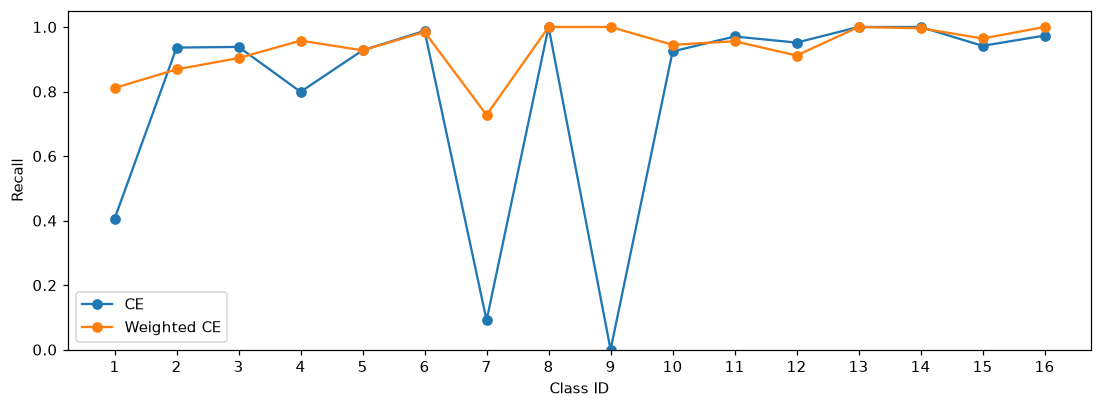

In [4]:
import json
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix
true=gt.ravel()[split['test_ids']]; results={}
for label,model in [('CE',ce),('Weighted CE',weighted)]:
    emb=encode_ids(model,cube,split['test_ids'],classifier=True)
    with torch.no_grad(): pred=np.asarray(cfg['classes'])[model.head(emb).argmax(1).numpy()]
    rec=recall_score(true,pred,labels=np.arange(1,17),average=None,zero_division=0)
    results[label]=(pred,rec)
    print(label,'OA:',accuracy_score(true,pred),'AA:',rec.mean(),'per-class recall:',rec)
fig,ax=plt.subplots(figsize=(12,4))
for label,(_,rec) in results.items(): ax.plot(np.arange(1,17),rec,'o-',label=label)
ax.set_xticks(np.arange(1,17)); ax.set_xlabel('Class ID'); ax.set_ylabel('Recall'); ax.set_ylim(0,1.05)
ax.legend(); plt.show()


{'case': 'Correct', 'pixel': (0, 0), 'true_id': 3, 'target_id': 3, 'true_name': 'Corn-mintill'}
{'case': 'Misclassified', 'pixel': (2, 28), 'true_id': 12, 'target_id': 3, 'true_name': 'Soybean-clean'}
{'case': 'Rare-class example', 'pixel': (61, 22), 'true_id': 9, 'target_id': 10, 'true_name': 'Oats'}


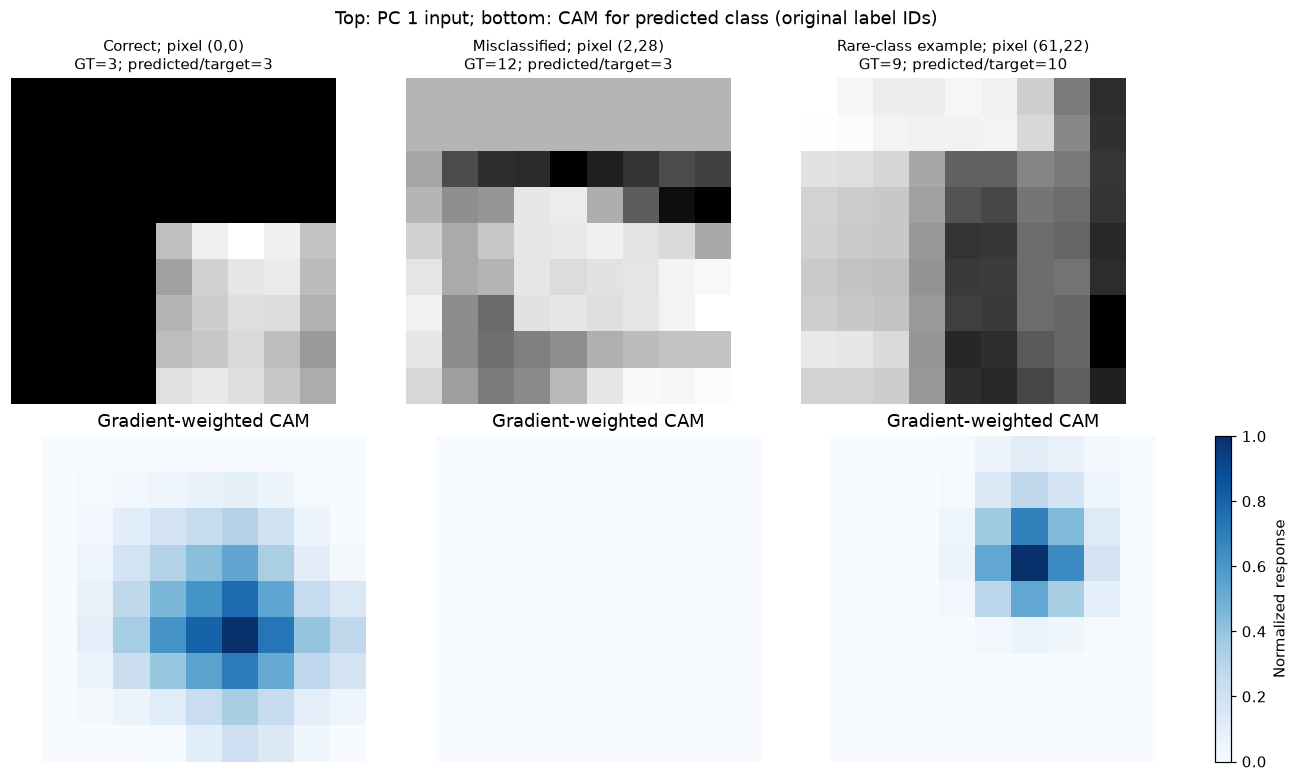

Zero CAM is possible. These are class-conditioned gradients, not a causal proof.
CAM shape: (3, 9, 9) finite: True


In [5]:
from hsi_learning.teaching_plots import cam_figure
# Explicit model selection; target gradients, not a mean activation proxy.
model=ce
cams,logits=cam_figure(model,cube,gt,split['test_ids'],cfg['patch_size'],cfg['classes'],names)
print('CAM shape:',tuple(cams.shape),'finite:',bool(torch.isfinite(cams).all()))


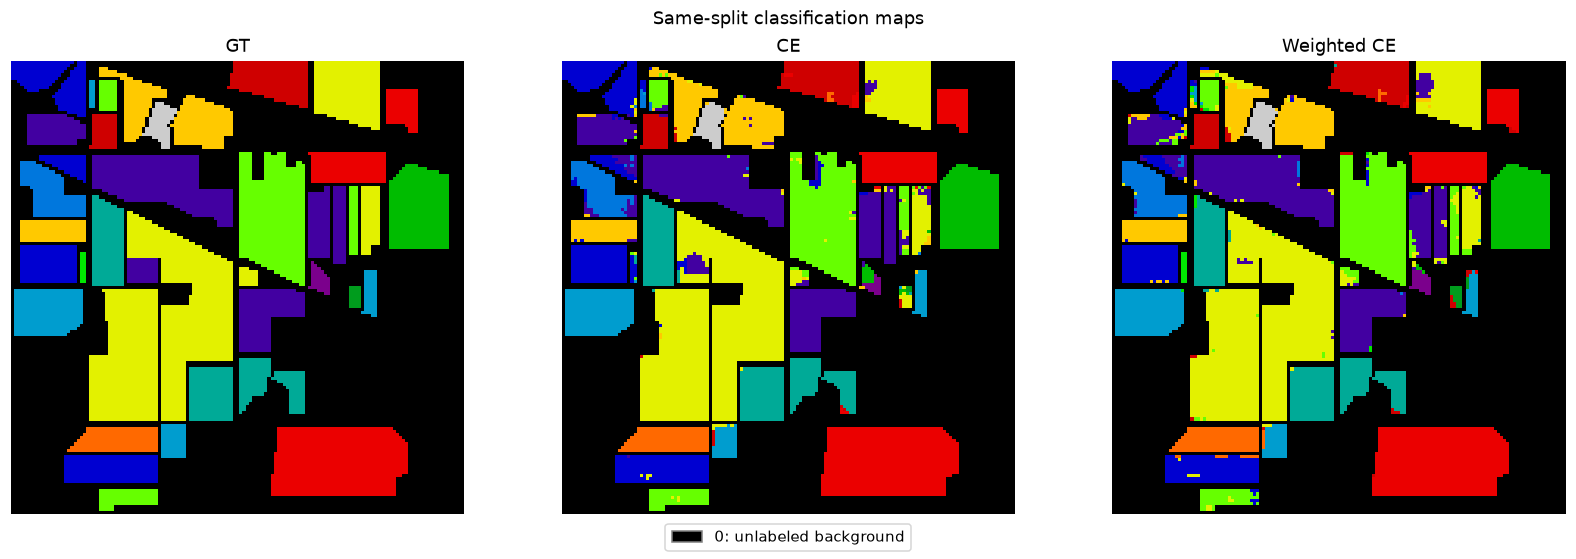

Class IDs: {1: 'Alfalfa', 2: 'Corn-notill', 3: 'Corn-mintill', 4: 'Corn', 5: 'Grass-pasture', 6: 'Grass-trees', 7: 'Grass-pasture-mowed', 8: 'Hay-windrowed', 9: 'Oats', 10: 'Soybean-notill', 11: 'Soybean-mintill', 12: 'Soybean-clean', 13: 'Wheat', 14: 'Woods', 15: 'Buildings-Grass-Trees-Drives', 16: 'Stone-Steel-Towers'}


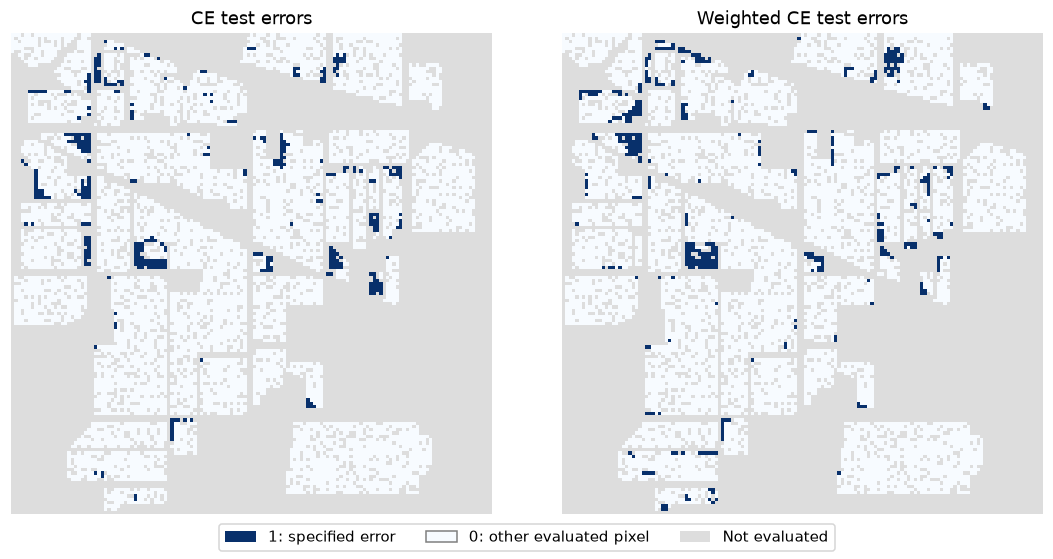

In [6]:
from hsi_learning.teaching_plots import classifier_maps
pred_ce,err_ce=classifier_maps(ce,cube,gt,split,cfg)
pred_w,err_w=classifier_maps(weighted,cube,gt,split,cfg)
maps(gt,{'GT':gt,'CE':pred_ce,'Weighted CE':pred_w},names,'Same-split classification maps')
from hsi_learning.teaching_plots import binary_error_style
fig,axes=plt.subplots(1,2,figsize=(10,5),layout='constrained')
error_cmap=binary_error_style(fig)
for ax,err,title in zip(axes,[err_ce,err_w],['CE test errors','Weighted CE test errors']):
    ax.imshow(err,cmap=error_cmap,vmin=0,vmax=1,interpolation='nearest'); ax.set_title(title); ax.axis('off')
plt.show()
plt.close(fig)


In [7]:
from scipy.ndimage import uniform_filter
ids=split['test_ids']; flat=gt.ravel()
coverage=np.zeros(gt.shape,dtype=float)
for c in range(1,17): coverage+=(gt==c)*uniform_filter((gt==c).astype(float),size=cfg['patch_size'],mode='constant')
values=coverage.ravel()[ids]
for lo,hi in [(0,.3),(.3,.8),(.8,1.00001)]:
    mask=(values>=lo)&(values<hi)
    print('Labeled same-class fraction:',lo,hi,'n=',int(mask.sum()))
    for label,(pred,_) in results.items(): print(label,float(np.mean(pred[mask]==true[mask])) if mask.any() else 'empty')
print('Unlabeled pixels reduce this fraction; it is NOT a complete land-cover purity label.')


Labeled same-class fraction: 0 0.3 n= 139
CE 0.5683453237410072
Weighted CE 0.5971223021582733
Labeled same-class fraction: 0.3 0.8 n= 4683
CE 0.9299594277172752
Weighted CE 0.919068972880632
Labeled same-class fraction: 0.8 1.00001 n= 3378
CE 0.9949674363528715
Weighted CE 0.9928952042628775
Unlabeled pixels reduce this fraction; it is NOT a complete land-cover purity label.


## 练习与证据边界
同一输入换目标类别，重新求Grad-CAM；热区是否变化？这仍不是因果证明。保持相同划分比较CE与加权CE，并报告代价，不只展示上涨的一项。完整训练用准备脚本；演示不加载未知来源旧权重。